# batch_instance CPU Max vs Avg Analysis

This notebook checks how often `cpu_max` is greater than `cpu_avg` in `batch_instance.csv` and summarizes the size of that gap.

It reads the CSV in chunks so it can handle the large raw trace file without loading everything into memory at once.

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path(r"E:/Cloud_Resource_Optimisation_thesis")
RAW_FILE = BASE_DIR / 'data' / 'raw' / 'clusterdata2018' / 'trace_201708' / 'batch_instance.csv'
RAW_FILE

WindowsPath('E:/Cloud_Resource_Optimisation_thesis/data/raw/clusterdata2018/trace_201708/batch_instance.csv')

In [25]:
import json
import numpy as np
from pathlib import Path

BASE_DIR = Path(r"E:/Cloud_Resource_Optimisation_thesis")
summary_path = BASE_DIR / 'data' / 'processed' / 'batch_instance_cpu_gap_summary.json'
print(summary_path)

with open(summary_path) as f:
    s = json.load(f)

o = s.get('overall', {})
t = s.get('terminated', {})

print((t.get('terminated_rows_analyzed',0), np.int64(t.get('cpu_max_gt_cpu_avg_rows',0)), np.int64(t.get('cpu_max_eq_cpu_avg_rows',0)), np.int64(t.get('cpu_max_lt_cpu_avg_rows',0))))
print("batch_instance CPU max vs avg")
print("=" * 60)
print(f"Overall rows analyzed      : {o.get('rows_analyzed',0):,}")
print(f"cpu_max > cpu_avg rows (overall): {o.get('cpu_max_gt_cpu_avg_rows',0):,} ({o.get('cpu_max_gt_cpu_avg_pct',0):.2f}%)")
print()
print(f"Terminated rows analyzed      : {t.get('terminated_rows_analyzed',0):,}")
print(f"cpu_max > cpu_avg rows        : {t.get('cpu_max_gt_cpu_avg_rows',0):,} ({t.get('cpu_max_gt_cpu_avg_pct',0):.2f}%)")
print(f"cpu_max = cpu_avg rows        : {t.get('cpu_max_eq_cpu_avg_rows',0):,} ({t.get('cpu_max_eq_cpu_avg_pct',0):.2f}%)")
print(f"cpu_max < cpu_avg rows        : {t.get('cpu_max_lt_cpu_avg_rows',0):,} ({t.get('cpu_max_lt_cpu_avg_pct',0):.2f}%)")
print()
print(f"Average gap (cpu_max - cpu_avg): {t.get('average_gap',0):.4f}")
print(f"Average positive gap only       : {t.get('average_positive_gap',0):.4f}")
print(f"Max gap observed                : {t.get('max_gap',0):.4f}")

E:\Cloud_Resource_Optimisation_thesis\data\processed\batch_instance_cpu_gap_summary.json
(13707867, np.int64(13561242), np.int64(144639), np.int64(1973))
batch_instance CPU max vs avg
Overall rows analyzed      : 16,094,656
cpu_max > cpu_avg rows (overall): 13,561,367 (84.26%)

Terminated rows analyzed      : 13,707,867
cpu_max > cpu_avg rows        : 13,561,242 (98.93%)
cpu_max = cpu_avg rows        : 144,639 (1.06%)
cpu_max < cpu_avg rows        : 1,973 (0.01%)

Average gap (cpu_max - cpu_avg): 0.8396
Average positive gap only       : 0.8487
Max gap observed                : 30.0300


In [26]:
pct_gt = (rows_cpu_max_gt_avg / total_rows * 100) if total_rows else 0
pct_eq = (rows_cpu_max_eq_avg / total_rows * 100) if total_rows else 0
pct_lt = (rows_cpu_max_lt_avg / total_rows * 100) if total_rows else 0
mean_gap = (gap_sum / total_rows) if total_rows else 0
mean_positive_gap = (gap_sum_positive / positive_gap_rows) if positive_gap_rows else 0

print('batch_instance CPU max vs avg')
print('=' * 60)
print(f'Terminated rows analyzed      : {total_rows:,}')
print(f'cpu_max > cpu_avg rows        : {rows_cpu_max_gt_avg:,} ({pct_gt:.2f}%)')
print(f'cpu_max = cpu_avg rows        : {rows_cpu_max_eq_avg:,} ({pct_eq:.2f}%)')
print(f'cpu_max < cpu_avg rows        : {rows_cpu_max_lt_avg:,} ({pct_lt:.2f}%)')
print()
print(f'Average gap (cpu_max - cpu_avg): {mean_gap:.4f}')
print(f'Average positive gap only       : {mean_positive_gap:.4f}')
print(f'Max gap observed                : {max_gap:.4f}')

if max_gap_row is not None:
    print('\nRow with the largest gap:')
    print(max_gap_row)

batch_instance CPU max vs avg
Terminated rows analyzed      : 13,707,867
cpu_max > cpu_avg rows        : 13,561,242 (98.93%)
cpu_max = cpu_avg rows        : 144,639 (1.06%)
cpu_max < cpu_avg rows        : 1,973 (0.01%)

Average gap (cpu_max - cpu_avg): 0.8396
Average positive gap only       : 0.8487
Max gap observed                : 30.0300

Row with the largest gap:
{'instance_name': 77665, 'task_name': 77667, 'job_name': nan, 'task_id': nan, 'start_time': 145.0, 'status': 'Terminated', 'seq_no': 1, 'total_seq_no': 1, 'cpu_max': 32.0, 'cpu_avg': 1.97, 'mem_max': nan, 'mem_avg': nan}



Comparison table (Overall vs Terminated):


,rows_analyzed,pct_cpu_max_gt,pct_cpu_max_eq,pct_cpu_max_lt,avg_gap
scope,,,,,
overall,16094656,84.260061,0.898677,0.012259,0.715129
terminated,13707867,98.930359,1.055153,0.014393,0.839620


Figure saved to: E:\Cloud_Resource_Optimisation_thesis\data\processed\batch_instance_comparison.png


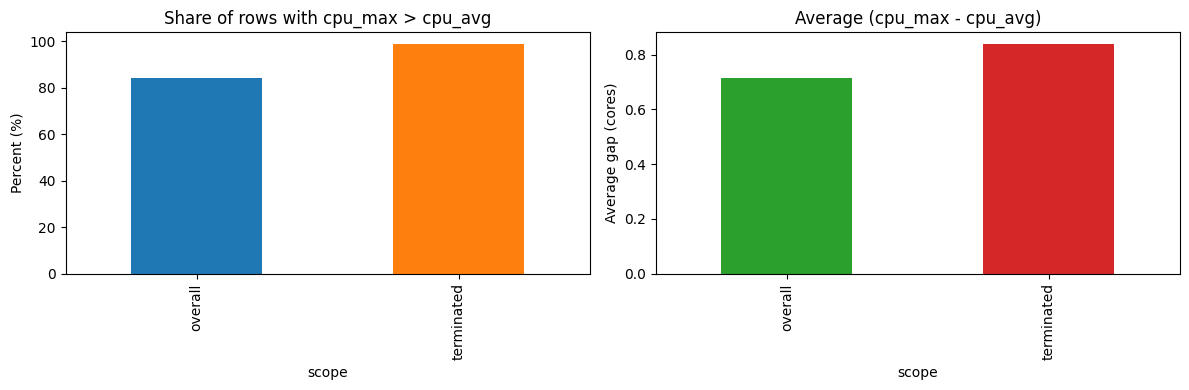

In [27]:
# Comparison table and plots for Overall vs Terminated
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(r"E:/Cloud_Resource_Optimisation_thesis")
summary_path = BASE_DIR / 'data' / 'processed' / 'batch_instance_cpu_gap_summary.json'
out_path = BASE_DIR / 'data' / 'processed' / 'batch_instance_comparison.png'

with open(summary_path) as f:
    s = json.load(f)
o = s.get('overall', {})
t = s.get('terminated', {})

rows = [
    {
        'scope': 'overall',
        'rows_analyzed': int(o.get('rows_analyzed', 0)),
        'pct_cpu_max_gt': float(o.get('cpu_max_gt_cpu_avg_pct', 0)),
        'pct_cpu_max_eq': float(o.get('cpu_max_eq_cpu_avg_pct', 0)),
        'pct_cpu_max_lt': float(o.get('cpu_max_lt_cpu_avg_pct', 0)),
        'avg_gap': float(o.get('average_gap', 0))
    },
    {
        'scope': 'terminated',
        'rows_analyzed': int(t.get('terminated_rows_analyzed', 0)),
        'pct_cpu_max_gt': float(t.get('cpu_max_gt_cpu_avg_pct', 0)),
        'pct_cpu_max_eq': float(t.get('cpu_max_eq_cpu_avg_pct', 0)),
        'pct_cpu_max_lt': float(t.get('cpu_max_lt_cpu_avg_pct', 0)),
        'avg_gap': float(t.get('average_gap', 0))
    }
 ]
df = pd.DataFrame(rows).set_index('scope')

# Display table
print('\nComparison table (Overall vs Terminated):')
display(df)

# Plot: left = pct_cpu_max_gt, right = avg_gap
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['pct_cpu_max_gt'].plot(kind='bar', ax=axes[0], color=['#1f77b4','#ff7f0e'])
axes[0].set_ylabel('Percent (%)')
axes[0].set_title('Share of rows with cpu_max > cpu_avg')

df['avg_gap'].plot(kind='bar', ax=axes[1], color=['#2ca02c','#d62728'])
axes[1].set_ylabel('Average gap (cores)')
axes[1].set_title('Average (cpu_max - cpu_avg)')

plt.tight_layout()
fig.savefig(out_path)
print(f'Figure saved to: {out_path}')

---
## Notes on 'Overall' vs 'Terminated' analytics

This notebook now computes two summaries:

- **Overall**: statistics computed over all rows read from `batch_instance.csv` (all `status` values). Use this to understand dataset-wide behavior including running, pending, and other non-terminated records.
- **Terminated**: statistics computed only for rows where `status == 'Terminated'`. Use this for final utilization and rightsizing analysis because terminated records represent completed instances with full usage measurements.

Which to use:

- For capacity-planning and rightsizing answers, prefer **Terminated** (this is what most downstream cells use).
- For diagnostics, data quality checks, or to catch in-flight anomalies, inspect **Overall** as it includes non-terminated rows that may bias aggregates.

The printed outputs below show both summaries so you can compare them quickly. If you want, I can also add a small table or plot that directly compares the two side-by-side.